In [55]:
import cobra
from cobra.io import (
    load_json_model,
    save_json_model,
    load_matlab_model,
    save_matlab_model,
    read_sbml_model,
    write_sbml_model,
)
from cobra.flux_analysis import flux_variability_analysis
import numpy as np
import pandas as pd

In [56]:
M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")
M_xanthus

Name,myxo_model
Memory address,72f452efeba0
Number of metabolites,1224
Number of reactions,1339
Number of genes,1201
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [57]:
hdca_e = cobra.Metabolite(
    "hdca_e", formula="C16H31O2", name="Palmitate [e]", compartment="e"
)
M_xanthus.add_metabolites(hdca_e)  # add M_xanthus.metabolites.Biomass_e
M_xanthus.add_boundary(
    M_xanthus.metabolites.get_by_id("hdca_e"), type="exchange"
)  # add the exchange reaction for Biomass_e

MXAN_7040 = cobra.Gene(id="MXAN_7040", name="MXAN_7040", functional=True)

FAreaction = cobra.Reaction("rxn08704_c")
FAreaction.name = "Hexadecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)"  # Porin (Probably) so energy independant
FAreaction.subsystem = ""
FAreaction.lower_bound = -1000.0  # This is the default
FAreaction.upper_bound = 1000.0  # This is the default
hdca_e = M_xanthus.metabolites.hdca_e
hdca_c = M_xanthus.metabolites.hdca_c
FAreaction.add_metabolites(
    {hdca_e: -1, hdca_c: 1}
)  # add the metabolites to the reaction
FAreaction.gene_reaction_rule = "MXAN_7040"  # define which gene allow the reaction
M_xanthus.add_reactions([FAreaction])  # add the PR_Biomass reaction

M_xanthus.reactions.rxn08704_c.annotation = {
    "seed.reaction": "rxn08704",
    "bigg.reaction": ["FA160tp", "HDCAt", "HDCAtex", "HDCAtexi", "U209"],
    "metanetx.reaction": "MNXR99101",
}

M_xanthus.reactions.rxn08704_c

Ignoring reaction 'rxn08704_c' since it already exists.


Reaction identifier,rxn08704_c
Name,Hexadecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)
Memory address,0x72f4530a2ba0
Stoichiometry,hdca_e <=> hdca_c Palmitate [e] <=> Palmitate [c]
GPR,MXAN_7040
Lower bound,-1000.0
Upper bound,1000.0


In [58]:
liste = []
for i in M_xanthus.exchanges._dict:
    liste.append(i)
    print("M_xanthus.reactions." + i + ".lower_bound = 0")
    # print(i + ": " + M_xanthus.reactions.get_by_id(i).name)

M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_mg2_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_h2s_e.lower_bound = 0
M_xanthus.reactions.EX_so4_e.lower_bound = 0
M_xanthus.reactions.EX_pydx_e.lower_bound = 0
M_xanthus.reactions.EX_spmd_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lo

In [59]:
df = M_xanthus.summary().uptake_flux
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,1.065,0,0.00%
alaala_e,EX_alaala_e,507.1,6,22.22%
ca2_e,EX_ca2_e,0.355,0,0.00%
cl_e,EX_cl_e,0.355,0,0.00%
co2_e,EX_co2_e,0.9311,1,0.01%
cobalt2_e,EX_cobalt2_e,0.355,0,0.00%
cu2_e,EX_cu2_e,0.355,0,0.00%
glu_L_e,EX_glu_L_e,198.6,5,7.25%
hdca_e,EX_hdca_e,137.5,16,16.06%
his_L_e,EX_his_L_e,16.97,6,0.74%


In [60]:
## NON ESSENTIAL METABOLITES
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_salcn_e.lower_bound = 0
M_xanthus.reactions.EX_acgam_e.lower_bound = 0
M_xanthus.reactions.EX_pyr_e.lower_bound = 0
M_xanthus.reactions.EX_etoh_e.lower_bound = 0
M_xanthus.reactions.EX_but_e.lower_bound = 0
M_xanthus.reactions.EX_hom_L_e.lower_bound = 0
M_xanthus.reactions.EX_na1_e.lower_bound = 0
M_xanthus.reactions.EX_acald_e.lower_bound = 0
M_xanthus.reactions.EX_mobd_e.lower_bound = 0
M_xanthus.reactions.EX_metox_R_e.lower_bound = 0
M_xanthus.reactions.EX_arbt_e.lower_bound = 0
M_xanthus.reactions.EX_sucr_e.lower_bound = 0
M_xanthus.reactions.EX_galt_e.lower_bound = 0
M_xanthus.reactions.EX_glyb_e.lower_bound = 0
M_xanthus.reactions.EX_h2o_e.lower_bound = 0
M_xanthus.reactions.EX_so3_e.lower_bound = 0
M_xanthus.reactions.EX_h2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_n2o_e.lower_bound = 0
M_xanthus.reactions.EX_feenter_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_gam_e.lower_bound = 0
M_xanthus.reactions.EX_gly_cys_L_e.lower_bound = 0
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_h_e.lower_bound = 0
M_xanthus.reactions.EX_tre_e.lower_bound = 0
M_xanthus.reactions.EX_thr_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_malthx_e.lower_bound = 0
M_xanthus.reactions.EX_enter_e.lower_bound = 0
M_xanthus.reactions.EX_malttr_e.lower_bound = 0
M_xanthus.reactions.EX_arsni_e.lower_bound = 0
M_xanthus.reactions.EX_4hbz_e.lower_bound = 0
M_xanthus.reactions.EX_Butyro_betaine_e.lower_bound = 0
M_xanthus.reactions.EX_man_e.lower_bound = 0
M_xanthus.reactions.EX_chitob_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0
M_xanthus.reactions.EX_mal_D_e.lower_bound = 0
M_xanthus.reactions.EX_adocbl_e.lower_bound = 0
M_xanthus.reactions.EX_meoh_e.lower_bound = 0
M_xanthus.reactions.EX_succ_e.lower_bound = 0
M_xanthus.reactions.EX_glc_D_e.lower_bound = 0
M_xanthus.reactions.EX_acac_e.lower_bound = 0
M_xanthus.reactions.EX_no_e.lower_bound = 0
M_xanthus.reactions.EX_lac_D_e.lower_bound = 0
M_xanthus.reactions.EX_tsul_e.lower_bound = 0

## ESSENTIAL METABOLITES
M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
M_xanthus.reactions.EX_so4_e.lower_bound = -1000
M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
M_xanthus.reactions.EX_pi_e.lower_bound = -1000
M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
M_xanthus.reactions.EX_k_e.lower_bound = -1000
M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
M_xanthus.reactions.EX_cl_e.lower_bound = -1000
M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
M_xanthus.reactions.EX_o2_e.lower_bound = -1000
M_xanthus.reactions.EX_hdca_e.lower_bound = -1000

In [61]:
FBA = M_xanthus.optimize()
FBA.objective_value

52.531708273294186

In [62]:
M_xanthus.metabolites.co2_e.summary()

Percent,Flux,Reaction,Definition
Percent,Flux,Reaction,Definition


In [63]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


Test taking random value between a range

In [64]:
FVA = flux_variability_analysis(
    M_xanthus,
)

for i in liste:
    if FVA.loc[i][0] < 0:
        rdm = np.random.uniform(
            FVA.loc[i][0], FVA.loc[i][1]
        )  # get a random value between two point
        print(i + ": " + "\n" + "random   " + str(rdm) + "\n" + str(FVA.loc[i]))

EX_mg2_e: 
random   -0.08405286930466009
minimum   -0.084053
maximum   -0.084053
Name: EX_mg2_e, dtype: float64
EX_h2s_e: 
random   -12.081636830261312
minimum   -12.081637
maximum   -12.081637
Name: EX_h2s_e, dtype: float64
EX_so4_e: 
random   -0.08405286966490845
minimum   -0.084053
maximum   -0.084053
Name: EX_so4_e, dtype: float64
EX_pydx_e: 
random   -0.08405286952648522
minimum   -0.084053
maximum   -0.084053
Name: EX_pydx_e, dtype: float64
EX_spmd_e: 
random   -0.08405286952638781
minimum   -0.084053
maximum   -0.084053
Name: EX_spmd_e, dtype: float64
EX_pi_e: 
random   -34.72186375679178
minimum   -34.721864
maximum   -34.721864
Name: EX_pi_e, dtype: float64
EX_leu_L_e: 
random   -19.032956575257174
minimum   -19.032957
maximum   -19.032957
Name: EX_leu_L_e, dtype: float64
EX_k_e: 
random   -0.0840528693046308
minimum   -0.084053
maximum   -0.084053
Name: EX_k_e, dtype: float64
EX_cu2_e: 
random   -0.08405286930464353
minimum   -0.084053
maximum   -0.084053
Name: EX_cu2_e, dtyp

/tmp/ipykernel_3823/2419264253.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if FVA.loc[i][0] < 0:
/tmp/ipykernel_3823/2419264253.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FVA.loc[i][0], FVA.loc[i][1]


In [65]:
np.random.uniform(
    FVA.loc["EX_hdca_e"][0], FVA.loc["EX_hdca_e"][1]
)  # get a random value between two point

/tmp/ipykernel_3823/922389116.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FVA.loc["EX_hdca_e"][0], FVA.loc["EX_hdca_e"][1]


-116.11365249147558

Look at all FA available on the model

In [66]:
for i in M_xanthus.metabolites:
    if (
        "C16" in i.formula
        or "C14" in i.formula
        or "C18" in i.formula
        or "C12" in i.formula
        or "C20" in i.formula
    ):
        if (
            "N" not in i.formula
            and "S" not in i.formula
            and "P" not in i.formula
            and "O2" in i.formula
        ):
            print(i.name + "[" + i.id + "]: " + i.formula)

fa6 [c][fa6_c]: C16H31O2
hexadecenoate [c][hdcea_c]: C16H29O2
ddca [c][ddca_c]: C12H23O2
octadecenoate [c][ocdcea_c]: C18H33O2
Palmitate [c][hdca_c]: C16H31O2
Estrone [c][Estrone_c]: C18H22O2
ocdca [c][ocdca_c]: C18H35O2
Myristic acid [c][ttdca_c]: C14H27O2
tetradecenoate [c][ttdcea_c]: C14H25O2
fa1 [c][fa1_c]: C14H27O2
Palmitate [e][hdca_e]: C16H31O2


**Others FA**

ttdca: Myristic Acid

In [67]:
M_xanthus = read_sbml_model("../M_xanthus_model_V3_hdca.xml")
M_xanthus

Name,myxo_model
Memory address,72f452309c10
Number of metabolites,1224
Number of reactions,1339
Number of genes,1201
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [68]:
ttdca_e = cobra.Metabolite(
    "ttdca_e", formula="C14H27O2", name="Myristic acid [e]", compartment="e"
)
M_xanthus.add_metabolites(ttdca_e)  # add M_xanthus.metabolites.Biomass_e
M_xanthus.add_boundary(
    M_xanthus.metabolites.get_by_id("ttdca_e"), type="exchange"
)  # add the exchange reaction for Biomass_e

MXAN_7040 = cobra.Gene(id="MXAN_7040", name="MXAN_7040", functional=True)

FAreaction = cobra.Reaction("rxn09331_c")
FAreaction.name = "Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)"  # Porin (Probably) so energy independant
FAreaction.subsystem = ""
FAreaction.lower_bound = -1000.0  # This is the default
FAreaction.upper_bound = 1000.0  # This is the default
ttdca_e = M_xanthus.metabolites.ttdca_e
ttdca_c = M_xanthus.metabolites.ttdca_c
FAreaction.add_metabolites(
    {ttdca_e: -1, ttdca_c: 1}
)  # add the metabolites to the reaction
FAreaction.gene_reaction_rule = "MXAN_7040"  # define which gene allow the reaction
M_xanthus.add_reactions([FAreaction])  # add the PR_Biomass reaction

M_xanthus.reactions.rxn09331_c.annotation = {
    "seed.reaction": "rxn09331",
    "bigg.reaction": [" FA140tp", "TTDCAt", "TTDCAtex", "TTDCAtexi", "TTDCAtr", "U208"],
    "metanetx.reaction": "MNXR128297",
}

M_xanthus.reactions.rxn09331_c

Reaction identifier,rxn09331_c
Name,Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)
Memory address,0x72f4540d2720
Stoichiometry,ttdca_e <=> ttdca_c Myristic acid [e] <=> Myristic acid [c]
GPR,MXAN_7040
Lower bound,-1000.0
Upper bound,1000.0


In [69]:
## NON ESSENTIAL METABOLITES
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_salcn_e.lower_bound = 0
M_xanthus.reactions.EX_acgam_e.lower_bound = 0
M_xanthus.reactions.EX_pyr_e.lower_bound = 0
M_xanthus.reactions.EX_etoh_e.lower_bound = 0
M_xanthus.reactions.EX_but_e.lower_bound = 0
M_xanthus.reactions.EX_hom_L_e.lower_bound = 0
M_xanthus.reactions.EX_na1_e.lower_bound = 0
M_xanthus.reactions.EX_acald_e.lower_bound = 0
M_xanthus.reactions.EX_mobd_e.lower_bound = 0
M_xanthus.reactions.EX_metox_R_e.lower_bound = 0
M_xanthus.reactions.EX_arbt_e.lower_bound = 0
M_xanthus.reactions.EX_sucr_e.lower_bound = 0
M_xanthus.reactions.EX_galt_e.lower_bound = 0
M_xanthus.reactions.EX_glyb_e.lower_bound = 0
M_xanthus.reactions.EX_h2o_e.lower_bound = 0
M_xanthus.reactions.EX_so3_e.lower_bound = 0
M_xanthus.reactions.EX_h2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_n2o_e.lower_bound = 0
M_xanthus.reactions.EX_feenter_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_gam_e.lower_bound = 0
M_xanthus.reactions.EX_gly_cys_L_e.lower_bound = 0
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_h_e.lower_bound = 0
M_xanthus.reactions.EX_tre_e.lower_bound = 0
M_xanthus.reactions.EX_thr_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_malthx_e.lower_bound = 0
M_xanthus.reactions.EX_enter_e.lower_bound = 0
M_xanthus.reactions.EX_malttr_e.lower_bound = 0
M_xanthus.reactions.EX_arsni_e.lower_bound = 0
M_xanthus.reactions.EX_4hbz_e.lower_bound = 0
M_xanthus.reactions.EX_Butyro_betaine_e.lower_bound = 0
M_xanthus.reactions.EX_man_e.lower_bound = 0
M_xanthus.reactions.EX_chitob_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0
M_xanthus.reactions.EX_mal_D_e.lower_bound = 0
M_xanthus.reactions.EX_adocbl_e.lower_bound = 0
M_xanthus.reactions.EX_meoh_e.lower_bound = 0
M_xanthus.reactions.EX_succ_e.lower_bound = 0
M_xanthus.reactions.EX_glc_D_e.lower_bound = 0
M_xanthus.reactions.EX_acac_e.lower_bound = 0
M_xanthus.reactions.EX_no_e.lower_bound = 0
M_xanthus.reactions.EX_lac_D_e.lower_bound = 0
M_xanthus.reactions.EX_tsul_e.lower_bound = 0

## ESSENTIAL METABOLITES
M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
M_xanthus.reactions.EX_so4_e.lower_bound = -1000
M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
M_xanthus.reactions.EX_pi_e.lower_bound = -1000
M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
M_xanthus.reactions.EX_k_e.lower_bound = -1000
M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
M_xanthus.reactions.EX_cl_e.lower_bound = -1000
M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
M_xanthus.reactions.EX_o2_e.lower_bound = -1000
M_xanthus.reactions.EX_ttdca_e.lower_bound = -1000
# M_xanthus.reactions.EX_hdca_e.lower_bound = -1000

In [70]:
FBA = M_xanthus.optimize()
FBA.objective_value

52.5317082732141

In [71]:
M_xanthus.genes.MXAN_7040

Gene identifier,MXAN_7040
Name,G_MXAN_7040
Memory address,0x72f453371af0
Functional,True
In 2 reaction(s),"rxn08704_c, rxn09331_c"


In [72]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3362,0,0.00%
ca2_e,EX_ca2_e,0.08405,0,0.00%
cl_e,EX_cl_e,0.08405,0,0.00%
cobalt2_e,EX_cobalt2_e,0.08405,0,0.00%
cu2_e,EX_cu2_e,0.08405,0,0.00%
h2s_e,EX_h2s_e,12.08,0,0.00%
hdca_e,EX_hdca_e,99.59,16,85.09%
ile_L_e,EX_ile_L_e,12.26,6,3.93%
k_e,EX_k_e,0.08405,0,0.00%
leu_L_e,EX_leu_L_e,19.03,6,6.10%


fa1: Fatty Acid C14:0

fa6: Fatty Acid C16:0

In [73]:
M_xanthus.metabolites.ttdca_c.reactions

frozenset({<Reaction rxn05736_c at 0x72f451847500>,
           <Reaction rxn08441_c at 0x72f451c521e0>,
           <Reaction rxn08797_c at 0x72f4519cf650>,
           <Reaction rxn08804_c at 0x72f451d43b00>,
           <Reaction rxn08811_c at 0x72f451a82f90>,
           <Reaction rxn08818_c at 0x72f451b85f10>,
           <Reaction rxn08839_c at 0x72f451e83f50>,
           <Reaction rxn08846_c at 0x72f451e2a030>,
           <Reaction rxn09331_c at 0x72f4540d2720>})

In [74]:
M_xanthus = read_sbml_model("../M_xanthus_model_V3_hdca.xml")
M_xanthus

Name,myxo_model
Memory address,72f452e72d80
Number of metabolites,1224
Number of reactions,1339
Number of genes,1201
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [75]:
M_xanthus.metabolites.fa6_c

Metabolite identifier,fa6_c
Name,fa6 [c]
Memory address,0x72f45655af30
Formula,C16H31O2
Compartment,c
In 2 reaction(s),"rxn05280_c, rxn05250_c"


In [76]:
fa6_e = cobra.Metabolite(
    "fa6_e", formula="C16H31O2", name="Fatty Acid C16:0 [e]", compartment="e"
)
M_xanthus.add_metabolites(fa6_e)  # add M_xanthus.metabolites.Biomass_e
M_xanthus.add_boundary(
    M_xanthus.metabolites.get_by_id("fa6_e"), type="exchange"
)  # add the exchange reaction for Biomass_e

MXAN_7040 = cobra.Gene(id="MXAN_7040", name="MXAN_7040", functional=True)

FAreaction = cobra.Reaction("rxn09331_c")
FAreaction.name = "Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)"  # Porin (Probably) so energy independant
FAreaction.subsystem = ""
FAreaction.lower_bound = -1000.0  # This is the default
FAreaction.upper_bound = 1000.0  # This is the default
fa6_e = M_xanthus.metabolites.fa6_e
fa6_c = M_xanthus.metabolites.fa6_c
FAreaction.add_metabolites({fa6_e: -1, fa6_c: 1})  # add the metabolites to the reaction
FAreaction.gene_reaction_rule = "MXAN_7040"  # define which gene allow the reaction
M_xanthus.add_reactions([FAreaction])  # add the PR_Biomass reaction

M_xanthus.reactions.rxn09331_c.annotation = {
    "seed.reaction": "rxn09331",
    "bigg.reaction": [" FA140tp", "TTDCAt", "TTDCAtex", "TTDCAtexi", "TTDCAtr", "U208"],
    "metanetx.reaction": "MNXR128297",
}

M_xanthus.reactions.rxn09331_c

Reaction identifier,rxn09331_c
Name,Tetradecanoate transport via facilitated irreversible diffusion (extracellular to periplasm)
Memory address,0x72f453dcb590
Stoichiometry,fa6_e <=> fa6_c Fatty Acid C16:0 [e] <=> fa6 [c]
GPR,MXAN_7040
Lower bound,-1000.0
Upper bound,1000.0


In [77]:
## NON ESSENTIAL METABOLITES
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_salcn_e.lower_bound = 0
M_xanthus.reactions.EX_acgam_e.lower_bound = 0
M_xanthus.reactions.EX_pyr_e.lower_bound = 0
M_xanthus.reactions.EX_etoh_e.lower_bound = 0
M_xanthus.reactions.EX_but_e.lower_bound = 0
M_xanthus.reactions.EX_hom_L_e.lower_bound = 0
M_xanthus.reactions.EX_na1_e.lower_bound = 0
M_xanthus.reactions.EX_acald_e.lower_bound = 0
M_xanthus.reactions.EX_mobd_e.lower_bound = 0
M_xanthus.reactions.EX_metox_R_e.lower_bound = 0
M_xanthus.reactions.EX_arbt_e.lower_bound = 0
M_xanthus.reactions.EX_sucr_e.lower_bound = 0
M_xanthus.reactions.EX_galt_e.lower_bound = 0
M_xanthus.reactions.EX_glyb_e.lower_bound = 0
M_xanthus.reactions.EX_h2o_e.lower_bound = 0
M_xanthus.reactions.EX_so3_e.lower_bound = 0
M_xanthus.reactions.EX_h2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_n2o_e.lower_bound = 0
M_xanthus.reactions.EX_feenter_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_gam_e.lower_bound = 0
M_xanthus.reactions.EX_gly_cys_L_e.lower_bound = 0
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_h_e.lower_bound = 0
M_xanthus.reactions.EX_tre_e.lower_bound = 0
M_xanthus.reactions.EX_thr_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_malthx_e.lower_bound = 0
M_xanthus.reactions.EX_enter_e.lower_bound = 0
M_xanthus.reactions.EX_malttr_e.lower_bound = 0
M_xanthus.reactions.EX_arsni_e.lower_bound = 0
M_xanthus.reactions.EX_4hbz_e.lower_bound = 0
M_xanthus.reactions.EX_Butyro_betaine_e.lower_bound = 0
M_xanthus.reactions.EX_man_e.lower_bound = 0
M_xanthus.reactions.EX_chitob_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0
M_xanthus.reactions.EX_mal_D_e.lower_bound = 0
M_xanthus.reactions.EX_adocbl_e.lower_bound = 0
M_xanthus.reactions.EX_meoh_e.lower_bound = 0
M_xanthus.reactions.EX_succ_e.lower_bound = 0
M_xanthus.reactions.EX_glc_D_e.lower_bound = 0
M_xanthus.reactions.EX_acac_e.lower_bound = 0
M_xanthus.reactions.EX_no_e.lower_bound = 0
M_xanthus.reactions.EX_lac_D_e.lower_bound = 0
M_xanthus.reactions.EX_tsul_e.lower_bound = 0

# M_xanthus.reactions.EX_fa1_e.lower_bound = 0
# M_xanthus.reactions.EX_fa6_e.lower_bound = 0

## ESSENTIAL METABOLITES
M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
M_xanthus.reactions.EX_so4_e.lower_bound = -1000
M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
M_xanthus.reactions.EX_pi_e.lower_bound = -1000
M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
M_xanthus.reactions.EX_k_e.lower_bound = -1000
M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
M_xanthus.reactions.EX_cl_e.lower_bound = -1000
M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
M_xanthus.reactions.EX_o2_e.lower_bound = -1000
M_xanthus.reactions.EX_hdca_e.lower_bound = -1000

In [78]:
FBA = M_xanthus.optimize()
FBA.objective_value

54.49652881062873

In [99]:
df2 = M_xanthus.summary().uptake_flux
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3488,0,0.00%
ca2_e,EX_ca2_e,0.0872,0,0.00%
cl_e,EX_cl_e,0.0872,0,0.00%
cobalt2_e,EX_cobalt2_e,0.0872,0,0.00%
cu2_e,EX_cu2_e,0.0872,0,0.00%
fa6_e,EX_fa6_e,18.7,16,15.40%
h2s_e,EX_h2s_e,12.53,0,0.00%
hdca_e,EX_hdca_e,90.46,16,74.50%
ile_L_e,EX_ile_L_e,12.72,6,3.93%
k_e,EX_k_e,0.0872,0,0.00%


In [100]:
df

,flux,reaction,metabolite
EX_Fe3_e,1.065057,EX_Fe3_e,Fe3_e
EX_alaala_e,507.117795,EX_alaala_e,alaala_e
EX_ca2_e,0.355019,EX_ca2_e,ca2_e
EX_cl_e,0.355019,EX_cl_e,cl_e
EX_co2_e,0.931140,EX_co2_e,co2_e
EX_cobalt2_e,0.355019,EX_cobalt2_e,cobalt2_e
EX_cu2_e,0.355019,EX_cu2_e,cu2_e
EX_glu_L_e,198.590783,EX_glu_L_e,glu_L_e
EX_hdca_e,137.482599,EX_hdca_e,hdca_e
EX_his_L_e,16.974534,EX_his_L_e,his_L_e


In [101]:
df2

,flux,reaction,metabolite
EX_Fe3_e,0.348787,EX_Fe3_e,Fe3_e
EX_ca2_e,0.087197,EX_ca2_e,ca2_e
EX_cl_e,0.087197,EX_cl_e,cl_e
EX_cobalt2_e,0.087197,EX_cobalt2_e,cobalt2_e
EX_cu2_e,0.087197,EX_cu2_e,cu2_e
EX_fa6_e,18.701282,EX_fa6_e,fa6_e
EX_h2s_e,12.533521,EX_h2s_e,h2s_e
EX_hdca_e,90.461995,EX_hdca_e,hdca_e
EX_ile_L_e,12.718205,EX_ile_L_e,ile_L_e
EX_k_e,0.087197,EX_k_e,k_e


In [102]:
df_row = [] 
for index, row in df.iterrows():
    df_row.append(index)

df_row2 = [] 
for index, row in df2.iterrows():
    df_row2.append(index)

In [ ]:
for i in df_row:
    if i not in df_row2:
        new_row = pd.DataFrame({"": [i],"flux": [0], "reaction": [i], "metabolites": [M_xanthus.reactions.get_by_id("EX_so4_e").reaction.split()[0]]})
        new_row = new_row.set_index("", inplace=True)
        print(new_row)
        df2 = pd.concat([df2, new_row], ignore_index=True)

             flux     reaction metabolites
index                                     
EX_alaala_e     0  EX_alaala_e       so4_e
          flux  reaction metabolites
index                               
EX_co2_e     0  EX_co2_e       so4_e
            flux    reaction metabolites
index                                   
EX_glu_L_e     0  EX_glu_L_e       so4_e
            flux    reaction metabolites
index                                   
EX_his_L_e     0  EX_his_L_e       so4_e
            flux    reaction metabolites
index                                   
EX_lys_L_e     0  EX_lys_L_e       so4_e
           flux   reaction metabolites
index                                 
EX_malt_e     0  EX_malt_e       so4_e
            flux    reaction metabolites
index                                   
EX_met_L_e     0  EX_met_L_e       so4_e
            flux    reaction metabolites
index                                   
EX_pheme_e     0  EX_pheme_e       so4_e
           flux   reaction m

In [104]:
df2

,flux,reaction,metabolite,metabolites
0,0.348787,EX_Fe3_e,Fe3_e,NaN
1,0.087197,EX_ca2_e,ca2_e,NaN
2,0.087197,EX_cl_e,cl_e,NaN
3,0.087197,EX_cobalt2_e,cobalt2_e,NaN
4,0.087197,EX_cu2_e,cu2_e,NaN
5,18.701282,EX_fa6_e,fa6_e,NaN
6,12.533521,EX_h2s_e,h2s_e,NaN
7,90.461995,EX_hdca_e,hdca_e,NaN
8,12.718205,EX_ile_L_e,ile_L_e,NaN
9,0.087197,EX_k_e,k_e,NaN


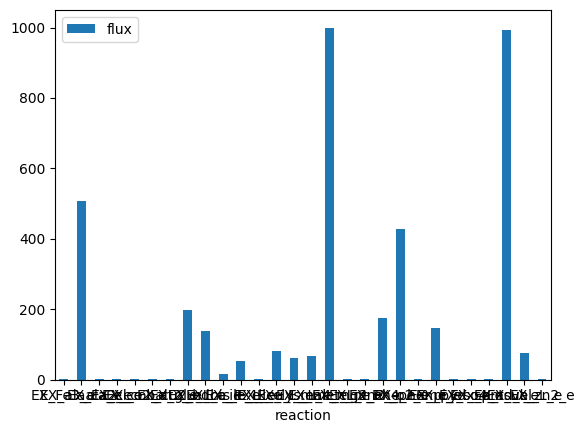

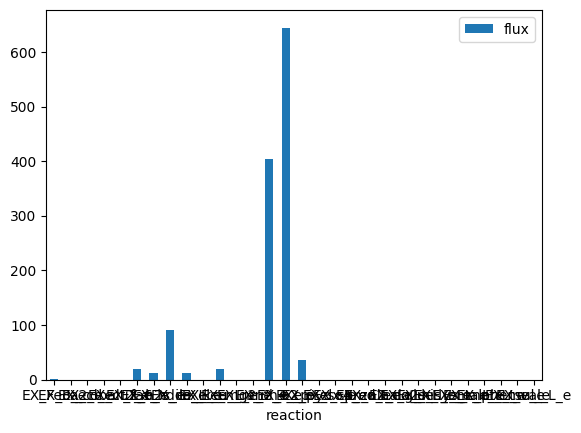

In [105]:
ax = df.plot.bar(x="reaction", y="flux", rot=0)
ax2 = df2.plot.bar(x="reaction", y="flux", rot=0)